# Width versus depth on real satellite imagery

**Question:** At approximately equal parameter counts, how do residual-CNN width and depth affect land-cover classification accuracy and execution cost?

One seed, three residual CNNs, real EuroSAT RGB images, and one independent training cell per shape. All reusable implementation lives in `src`. The initial configuration keeps your **one epoch**. Execute whichever model cell you want; no other model must finish first. With RUN_TRAINING=True, Run All executes all three training cells sequentially.

This revision removes the separate timing-pilot workflow and GPU-activity collector. Basic epoch metrics, timings, memory snapshots, checkpoint recovery and joint saved-result charts remain. You removed the old runs during this revision. Protocol v3 creates a fresh numbered run and reuses the verified data cache.

Choose the desired epoch limit before creating a full-comparison run. Changing it later requires a fresh run. One epoch is a short execution check, not evidence of converged model quality. Test evaluation and benchmarks are disabled initially. No model or notebook execution was performed during this revision.


### Imports

Load reusable project interfaces without starting data preparation or training.

**Inputs:** The isolated EuroSAT Width–Depth — Python 3.13 kernel and this project folder.

**Output:** Python functions ready for explicit calls.

**Interpretation:** Restart the named kernel if another project already imported a package named src.

In [1]:
import sys
from pathlib import Path

candidates = (Path.cwd(), Path.cwd().parent, Path.cwd() / "labs" / "eurosat-width-depth")
ROOT = next((p.resolve() for p in candidates if (p / "src" / "config.py").exists() and p.name == "eurosat-width-depth"), None)
if ROOT is None:
    raise RuntimeError("Open this notebook from the eurosat-width-depth project")
sys.path.insert(0, str(ROOT))
import src

if Path(src.__file__).resolve().parent != ROOT / "src":
    raise RuntimeError("Restart the EuroSAT kernel: another project's src is already imported")
from IPython.display import display

from src.benchmark import benchmark_fit
from src.config import ExperimentConfig, TrainingConfig
from src.data import prepare_data
from src.eda import class_distribution, dataset_overview, plot_training_rgb, show_training_examples
from src.evaluate import evaluate_fit, freeze_selection
from src.models import architecture_table
from src.reporting import (
    assemble_report,
    benchmark_table,
    epoch_table,
    failure_table,
    plot_accuracy_runtime,
    plot_confusions,
    plot_epoch_costs,
    plot_learning_curves,
    plot_memory,
    plot_quality,
    plot_throughput,
    quality_table,
)
from src.runs import resolve_run
from src.runtime import device_information
from src.train import train_fit, training_status


### Configuration — edit here

Set the training recipe and optional notebook stages.

**Inputs:** One seed and the three registered shapes; the notebook starts at max_epochs=1.

**Output:** Configuration and execution controls; nothing starts here.

**Interpretation:** With RUN_TRAINING=True, each training cell runs its named model. Execute individual cells to choose a model, or Run All to train all three sequentially. RUN_TRAINING=False skips training cells. Choose your final max_epochs before creating a new run. Test evaluation needs all three completed fits. Set RUN_DIR to the created directory when resuming; None deliberately creates another run.


In [2]:
RUN_DIR = None
USE_SAVED_CONFIG = True
CONFIG = ExperimentConfig(
    training=TrainingConfig(seed=42, max_epochs=40, batch_size=128, validation_batch_size=256),
)
RUN_TRAINING = True
RUN_TEST_EVALUATION = True
RUN_BENCHMARKS = True
SHOW_TENSORBOARD = False


### Create or resume one run

Allocate the next directory or verify the explicitly selected saved run.

**Inputs:** ROOT, CONFIG, RUN_DIR and USE_SAVED_CONFIG.

**Output:** The selected run directory and effective saved settings.

**Interpretation:** RUN_DIR=None creates a fresh run each time this cell executes. Copy the printed name into RUN_DIR before resuming. Saved settings take precedence when USE_SAVED_CONFIG=True. Source, environment, backend and dataset checks stay strict; earlier protocols cannot resume with this source.


In [3]:
run = resolve_run(ROOT, CONFIG, RUN_DIR, USE_SAVED_CONFIG)
display(run.path, run.config.to_dict())

Created run_001; fresh weights; hash=a3f472af4384d41e2ec90439ca15b08c73e97404aa0172b286f202ea33e9fdf3


PosixPath('/Users/biitu/Documents/Growth/labs/eurosat-width-depth/runs/run_001')

{'data': {'archive_url': 'https://zenodo.org/records/7711810/files/EuroSAT_RGB.zip',
  'archive_md5': 'f46e308c4d50d4bf32fedad2d3d62f3b',
  'split_base_url': 'https://hf.co/datasets/torchgeo/eurosat/resolve/1ce6f1bfb56db63fd91b6ecc466ea67f2509774c/',
  'image_size': 64,
  'expected_images': 27000,
  'classes': 10},
 'models': ({'name': 'shallow_wide', 'blocks_per_stage': 1, 'base_width': 48},
  {'name': 'middle', 'blocks_per_stage': 2, 'base_width': 32},
  {'name': 'deep_narrow', 'blocks_per_stage': 4, 'base_width': 22}),
 'training': {'seed': 42,
  'max_epochs': 40,
  'batch_size': 128,
  'validation_batch_size': 256,
  'learning_rate': 0.001,
  'min_learning_rate': 1e-05,
  'weight_decay': 0.0001,
  'gradient_clip': 1.0,
  'num_workers': 0,
  'horizontal_flip': True,
  'vertical_flip': True},
 'benchmark': {'batch_sizes': (1, 64), 'warmups': 5, 'repetitions': 30},
 'max_parameter_spread': 0.05,
 'protocol': 'eurosat-width-depth-v3'}

### Device

Inspect the backend before starting work.

**Inputs:** This run’s selected backend.

**Output:** Backend and available memory snapshots.

**Interpretation:** MPS has priority. Memory snapshots do not measure peak use or GPU utilization; unsupported backend operations stop the fit.

In [4]:
device_information(run)

{'device': 'mps',
 'precision': 'float32',
 'gpu_name': 'Apple Metal (MPS)',
 'memory_definition': 'Snapshots; process RSS and accelerator allocations are not additive',
 'process_rss_mib': 292.46875,
 'mps_live_mib': 0.0,
 'mps_driver_mib': 0.375}

### Saved progress

Read the completion and resume state of each shape.

**Inputs:** Current run artifacts.

**Output:** Joint status table.

**Interpretation:** A completed fit is verified and reused. An interrupted epoch restarts from the previous committed epoch; notebook idle time is excluded. Saved states do not establish that a kernel is currently running.

In [5]:
training_status(run)

,stage,variant,state,completed_epoch,best_epoch
0,models,shallow_wide,not_started,0,None
1,models,middle,not_started,0,None
2,models,deep_narrow,not_started,0,None


## Data and training-only EDA

The first preparation call downloads the official RGB archive and pinned spatial split lists. Later calls verify and reuse the local cache. The test partition remains unavailable to model evaluation until all three selected checkpoints are frozen.

### Prepare the verified cache

Download if necessary, validate and cache native images once.

**Inputs:** Official EuroSAT RGB checksum and pinned TorchGeo spatial manifests.

**Output:** PreparedData, uint8 caches, split identities and training-only RGB statistics.

**Interpretation:** Every image must belong to exactly one published split. No labels, pixels or examples are silently dropped to satisfy a quota.

In [6]:
data = prepare_data(run)

### Dataset overview

Read the dataset dimensions, source and split sizes.

**Inputs:** Verified cache metadata.

**Output:** A metadata table saved in data_manifest/eda.

**Interpretation:** Counts describe coverage only. This is a ten-class RGB land-cover benchmark, not a multispectral or general real-world deployment evaluation.

In [7]:
dataset_overview(run, data)

,field,value
0,Dataset,EuroSAT RGB
1,Source,https://zenodo.org/records/7711810/files/EuroS...
2,Spatial split,Published TorchGeo longitude-based EuroSATSpat...
3,Image dimensions,"3 × 64 × 64; native RGB, no resize"
4,Image values,"Cached uint8 [0,255]; device normalization aft..."
5,Classes,10
6,Normalization fit,Training pixels only
7,Dataset identity,82e6e69a437f62d31cb0893ef2c1e63cf7a8a3f1ea4684...
8,test images,5400
9,train images,16200


### Class coverage

Compare class support in the split metadata and view training balance.

**Inputs:** Class counts only; the chart uses the training partition.

**Output:** A class-count table and training-count bar chart.

**Interpretation:** Class imbalance makes macro F1 useful beside accuracy. No validation/test image examples influence augmentation or normalization.

,class,test,train,val
0,AnnualCrop,818,1788,394
1,Forest,1077,1309,614
2,HerbaceousVegetation,816,1854,330
3,Highway,340,1698,462
4,Industrial,353,1659,488
5,Pasture,115,1767,118
6,PermanentCrop,307,1716,477
7,Residential,507,1927,566
8,River,331,1507,662
9,SeaLake,736,975,1289


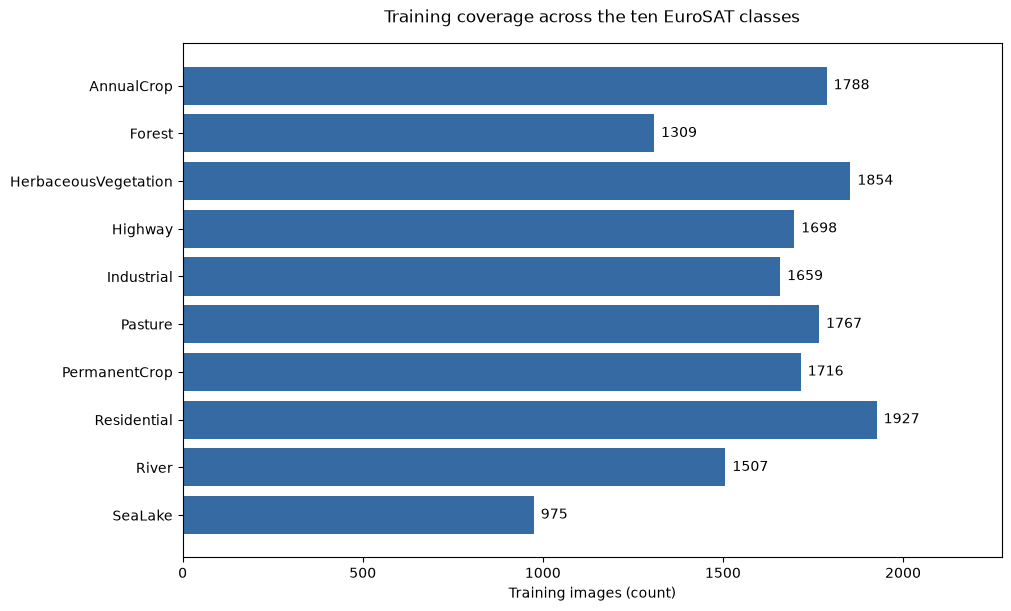

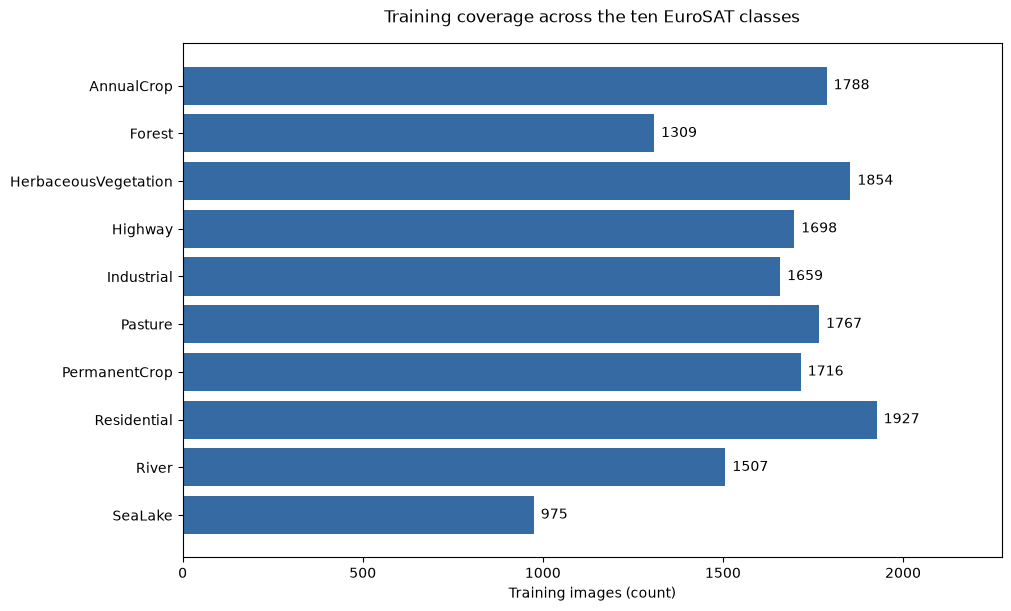

In [8]:
class_counts, class_count_figure = class_distribution(run, data)
display(class_counts)
display(class_count_figure)

### Real training images

Inspect deterministic examples from each class.

**Inputs:** Training images selected by filename, independent of results.

**Output:** Two image examples per class, with stable identifiers.

**Interpretation:** Some land-cover classes can be visually similar at 64×64. These are explanatory examples, not a hand-picked accuracy assessment.

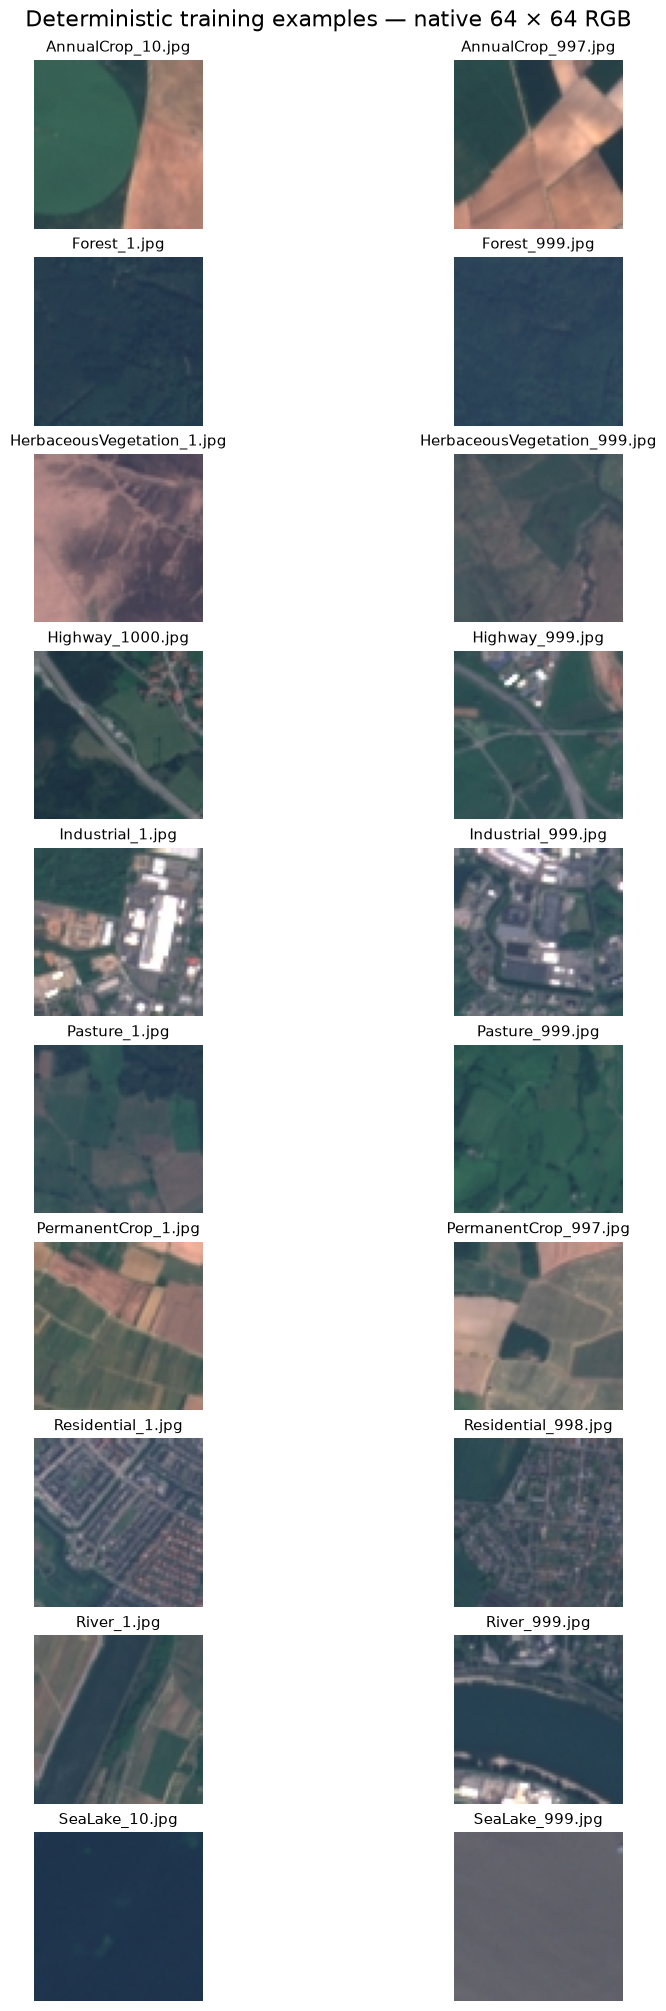

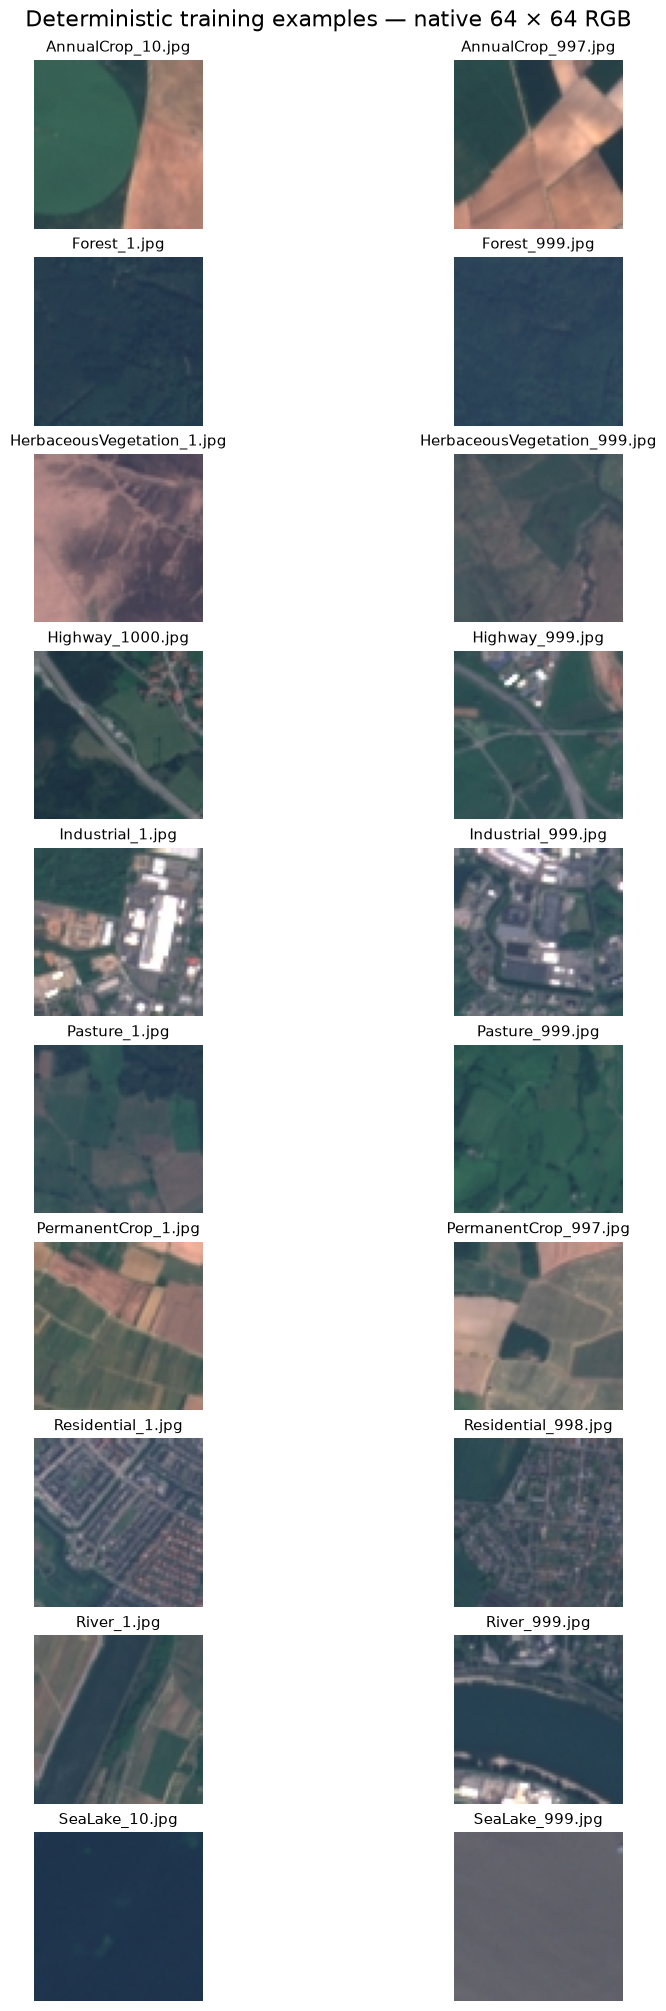

In [9]:
show_training_examples(run, data)

### RGB distributions

Inspect stored image intensity and fitted normalization.

**Inputs:** All training pixels for moments; a fixed 512-image training panel for histograms.

**Output:** RGB mean/std table and pixel-frequency curves.

**Interpretation:** Histogram values lie in 0–255. Normalization uses /255 moments fitted on training images only; it does not learn from either held-out split.

,channel,mean_rgb_div_255,std_rgb_div_255,fitted_partition
0,Red,0.364461,0.207139,train
1,Green,0.393029,0.134700,train
2,Blue,0.416771,0.116052,train


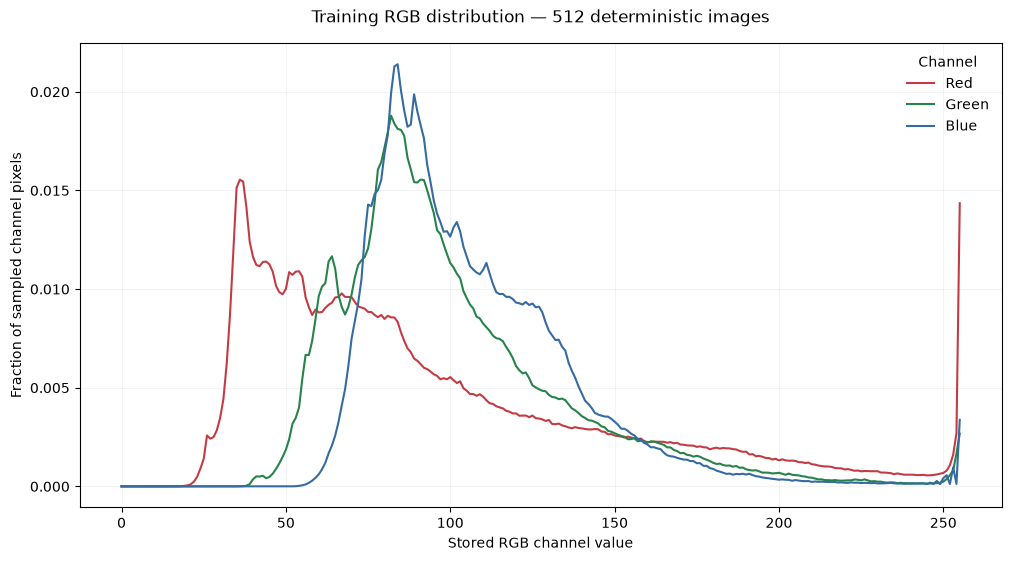

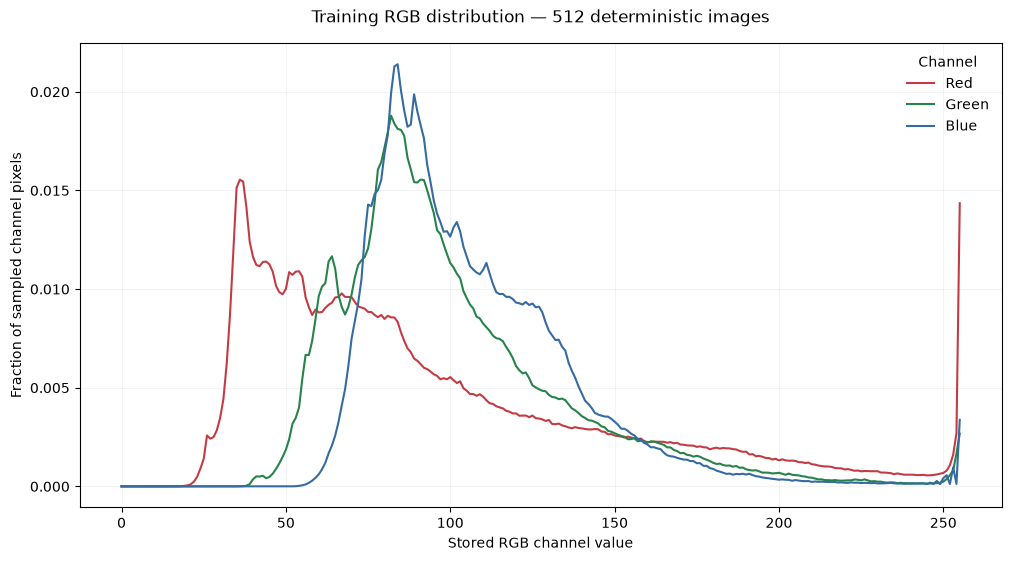

In [10]:
rgb_statistics, rgb_figure = plot_training_rgb(run, data)
display(rgb_statistics)
display(rgb_figure)

### Architecture comparison

Inspect all three shapes together and enforce parameter matching.

**Inputs:** The same three-stage residual-block definition with different widths and repeat counts.

**Output:** Layers, widths, parameter counts and the actual spread.

**Interpretation:** Defaults have 691,834 / 696,618 / 697,344 parameters (0.80% spread). Equal counts do not imply equal compute, receptive fields or learning difficulty.

In [11]:
architecture_table(run.config)

,variant,display_name,blocks_per_stage,residual_blocks,main_path_convolutions,shortcut_convolutions,base_width,stage_widths,parameters,trainable_parameters,stem_parameters,processing_block_parameters,classifier_parameters,parameter_bytes_fp32,comparison_parameter_spread
0,shallow_wide,Shallow / wide,1,3,7,2,48,48/96/192,691834,691834,1392,688512,1930,2767336,0.007964
1,middle,Middle,2,6,13,2,32,32/64/128,696618,696618,928,694400,1290,2786472,0.007964
2,deep_narrow,Deep / narrow,4,12,25,2,22,22/44/88,697344,697344,638,695816,890,2789376,0.007964


## Train one shape per cell

Each following cell initializes, resumes or reuses exactly its named model. There is one training path, with no prerequisite runs. Fresh models use the fixed AdamW/cosine recipe, FP32, seed 42 and the configured epoch limit. The starting configuration uses one epoch per shape.

To train a shape in the same experiment, execute its named cell. Run All executes the three training cells sequentially when RUN_TRAINING=True. Completed fits are verified and reused. An interrupted partial epoch restarts from the last committed epoch; the checkpoint restores optimizer, scheduler, RNG and loader-generator state. This is independent training, not simultaneous accelerator execution.


### Train / resume — Shallow / wide

Train, resume or reuse exactly this named shape.

**Inputs:** This run, verified training/validation data and the saved configuration.

**Output:** Architecture summary, best.pt, last.pt, epoch metrics, TensorBoard events and text logs under models/<shape>/seed_42/.

**Interpretation:** No other shape is launched or required. The highest validation accuracy selects best.pt, with loss and earliest epoch breaking ties. last.pt resumes training. When RUN_TRAINING=False, the cell prints “Not executed”; plotting and testing occur only in their own later cells.


In [12]:
train_fit(run, data, "shallow_wide") if RUN_TRAINING else print("Not executed: training disabled")


Train:   0%|          | 0/127 [00:00<?, ?it/s]

Validation:   0%|          | 0/22 [00:00<?, ?it/s]

Train:   0%|          | 0/127 [00:00<?, ?it/s]

Validation:   0%|          | 0/22 [00:00<?, ?it/s]

Train:   0%|          | 0/127 [00:00<?, ?it/s]

...

Train:   0%|          | 0/127 [00:00<?, ?it/s]

Validation:   0%|          | 0/22 [00:00<?, ?it/s]

Train:   0%|          | 0/127 [00:00<?, ?it/s]

Validation:   0%|          | 0/22 [00:00<?, ?it/s]

{'state': 'completed',
 'completed_epoch': 40,
 'best_epoch': 34,
 'global_step': 5080,
 'updated_at': '2026-09-23T11:18:39.970804+00:00',
 'reused': False}

### Train / resume — Middle

Train, resume or reuse exactly this named shape.

**Inputs:** This run, verified training/validation data and the saved configuration.

**Output:** Architecture summary, best.pt, last.pt, epoch metrics, TensorBoard events and text logs under models/<shape>/seed_42/.

**Interpretation:** No other shape is launched or required. The highest validation accuracy selects best.pt, with loss and earliest epoch breaking ties. last.pt resumes training. When RUN_TRAINING=False, the cell prints “Not executed”; plotting and testing occur only in their own later cells.


In [13]:
train_fit(run, data, "middle") if RUN_TRAINING else print("Not executed: training disabled")


Train:   0%|          | 0/127 [00:00<?, ?it/s]

Validation:   0%|          | 0/22 [00:00<?, ?it/s]

Train:   0%|          | 0/127 [00:00<?, ?it/s]

Validation:   0%|          | 0/22 [00:00<?, ?it/s]

Train:   0%|          | 0/127 [00:00<?, ?it/s]

...

Train:   0%|          | 0/127 [00:00<?, ?it/s]

Validation:   0%|          | 0/22 [00:00<?, ?it/s]

Train:   0%|          | 0/127 [00:00<?, ?it/s]

Validation:   0%|          | 0/22 [00:00<?, ?it/s]

{'state': 'completed',
 'completed_epoch': 40,
 'best_epoch': 34,
 'global_step': 5080,
 'updated_at': '2026-09-23T11:33:14.508095+00:00',
 'reused': False}

### Train / resume — Deep / narrow

Train, resume or reuse exactly this named shape.

**Inputs:** This run, verified training/validation data and the saved configuration.

**Output:** Architecture summary, best.pt, last.pt, epoch metrics, TensorBoard events and text logs under models/<shape>/seed_42/.

**Interpretation:** No other shape is launched or required. The highest validation accuracy selects best.pt, with loss and earliest epoch breaking ties. last.pt resumes training. When RUN_TRAINING=False, the cell prints “Not executed”; plotting and testing occur only in their own later cells.


In [14]:
train_fit(run, data, "deep_narrow") if RUN_TRAINING else print("Not executed: training disabled")


Train:   0%|          | 0/127 [00:00<?, ?it/s]

Validation:   0%|          | 0/22 [00:00<?, ?it/s]

Train:   0%|          | 0/127 [00:00<?, ?it/s]

Validation:   0%|          | 0/22 [00:00<?, ?it/s]

Train:   0%|          | 0/127 [00:00<?, ?it/s]

...

Train:   0%|          | 0/127 [00:00<?, ?it/s]

Validation:   0%|          | 0/22 [00:00<?, ?it/s]

Train:   0%|          | 0/127 [00:00<?, ?it/s]

Validation:   0%|          | 0/22 [00:00<?, ?it/s]

{'state': 'completed',
 'completed_epoch': 40,
 'best_epoch': 28,
 'global_step': 5080,
 'updated_at': '2026-09-23T12:04:06.776237+00:00',
 'reused': False}

### Completed epoch table

Compare saved metrics and timings across all three shapes.

**Inputs:** Verified completed-epoch records from the fits.

**Output:** A cumulative table saved under tables/.

**Interpretation:** Training accuracy uses augmented training images; validation accuracy uses unaugmented held-out images. Their difference is not solely overfitting.

In [15]:
epoch_table(run)

,checkpoint_seconds,epoch,epoch_seconds,gradient_norm,learning_rate,logging_seconds,mps_driver_mib,mps_live_mib,optimizer_updates,process_rss_mib,...,train_examples,train_examples_per_second,train_loss,train_seconds,validation_accuracy,validation_examples,validation_loss,validation_seconds,variant,cumulative_active_seconds
0,0.057581,1,27.831737,5.229255,0.001000,0.001534,3439.46875,42.865234,127,938.734375,...,16200,629.170962,0.793422,25.748169,0.622593,5400,1.236104,2.024219,shallow_wide,27.831737
1,0.048021,2,27.397922,6.059017,0.000998,0.001244,3439.46875,42.865234,127,939.640625,...,16200,637.342253,0.530902,25.418054,0.666481,5400,1.013086,1.930507,shallow_wide,55.229658
2,0.050075,3,27.131394,6.860417,0.000994,0.001217,3439.46875,42.865234,127,939.765625,...,16200,643.498332,0.435071,25.174890,0.759074,5400,0.715477,1.905110,shallow_wide,82.361052
3,0.041200,4,27.580212,7.050157,0.000986,0.001421,3439.46875,42.865234,127,939.906250,...,16200,632.572080,0.369252,25.609730,0.770370,5400,0.649670,1.927743,shallow_wide,109.941264
4,0.038460,5,27.292387,8.893165,0.000976,0.002195,3439.46875,42.865234,127,939.984375,...,16200,639.950427,0.333128,25.314461,0.583333,5400,1.778526,1.937137,shallow_wide,137.233651
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,0.082572,36,46.345440,0.724315,0.000048,0.001525,3266.78125,19.093262,127,484.390625,...,16200,370.982502,0.014648,43.667828,0.927407,5400,0.257491,2.593352,deep_narrow,1664.987973
116,0.078078,37,46.700491,0.744144,0.000034,0.002156,3266.78125,19.093262,127,484.500000,...,16200,367.764500,0.015898,44.049929,0.923704,5400,0.263213,2.570207,deep_narrow,1711.688464
117,0.076622,38,46.617005,0.706673,0.000024,0.002050,3266.78125,19.093262,127,485.125000,...,16200,368.438830,0.014173,43.969307,0.924259,5400,0.267543,2.568882,deep_narrow,1758.305468
118,0.080513,39,46.592777,0.685622,0.000016,0.001795,3266.78125,19.093262,127,485.203125,...,16200,368.757553,0.014363,43.931304,0.925370,5400,0.269549,2.579037,deep_narrow,1804.898245


### Joint learning curves

Compare loss and accuracy over training.

**Inputs:** Saved per-epoch train/validation loss and accuracy for all shapes.

**Output:** Joint loss and accuracy charts with consistent colors.

**Interpretation:** Lower cross-entropy and higher accuracy are better. Dashed lines are training; solid lines validation. One seed means there are no seed-uncertainty bands.

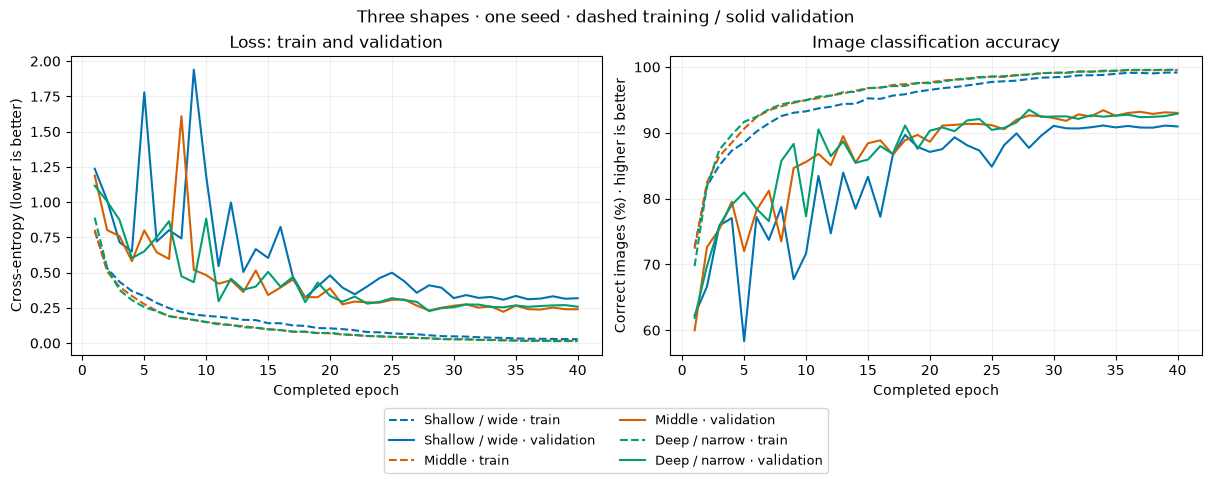

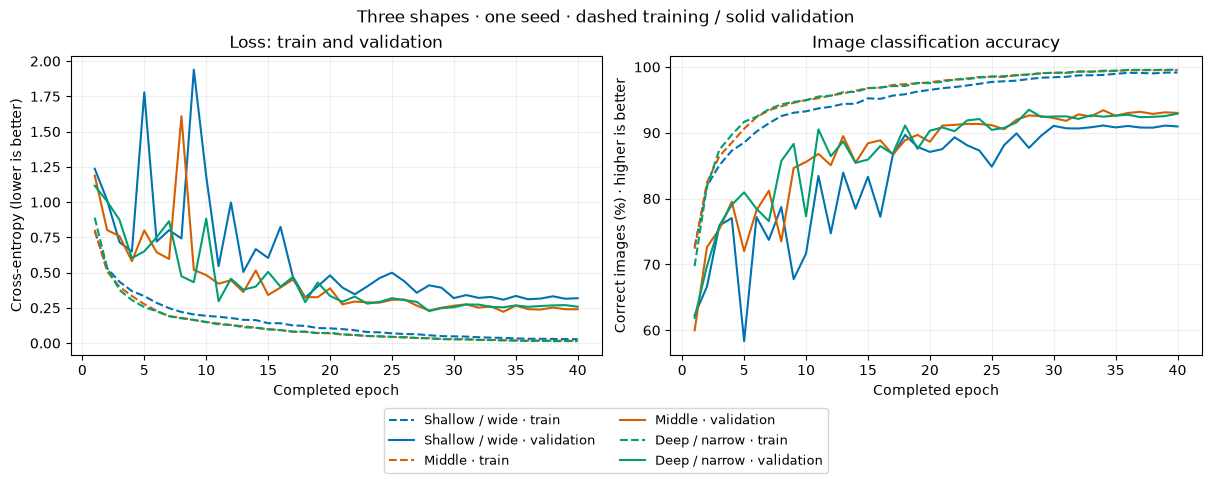

In [16]:
plot_learning_curves(run)

### Epoch costs

Locate where each shape spends its measured epoch time.

**Inputs:** Full-fit timing receipts.

**Output:** Epoch timelines and mean recorded phase costs.

**Interpretation:** Training and validation boundaries are separate. Missing receipts remain missing; Final receipt/table/TensorBoard timing-series publication is outside epoch_seconds. The charts are measurements rather than a predicted exact cost model.

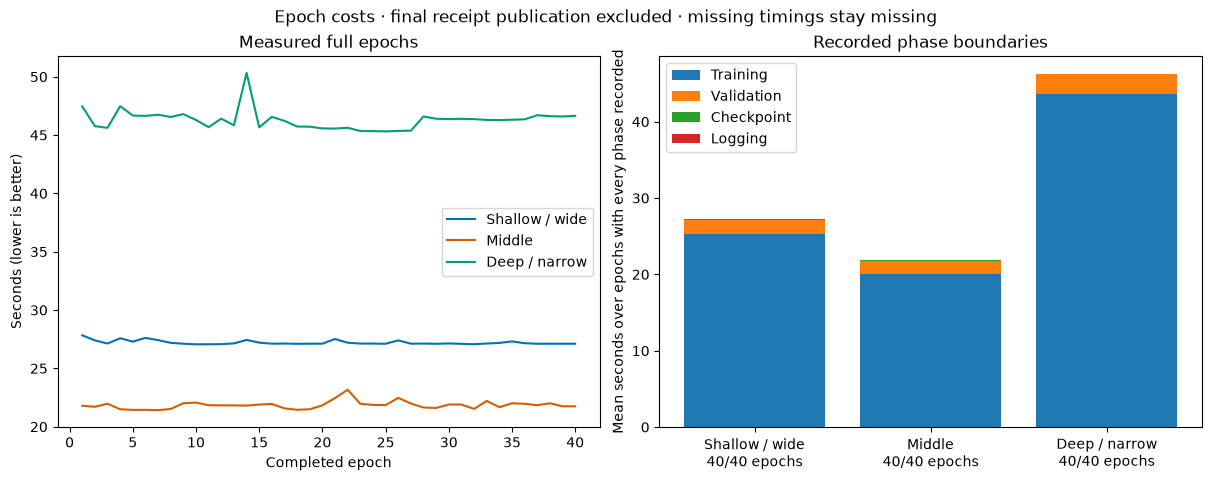

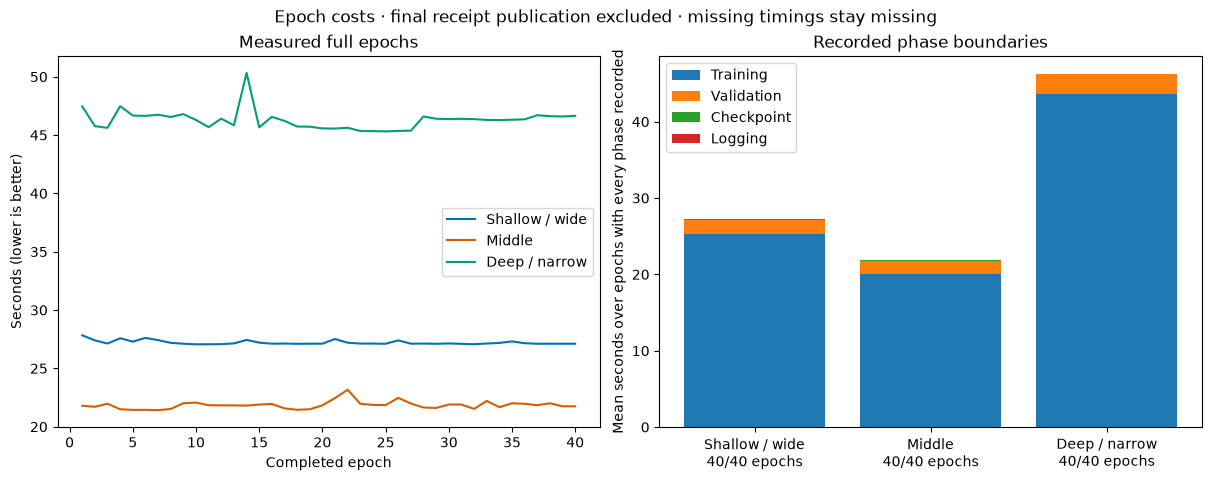

In [17]:
plot_epoch_costs(run)

### Training throughput

Compare images processed per second of training.

**Inputs:** Training image counts divided by measured training wall time.

**Output:** All three shapes on one chart.

**Interpretation:** Higher is faster at these settings. This includes loading, augmentation and optimizer work; it is not isolated convolution throughput.

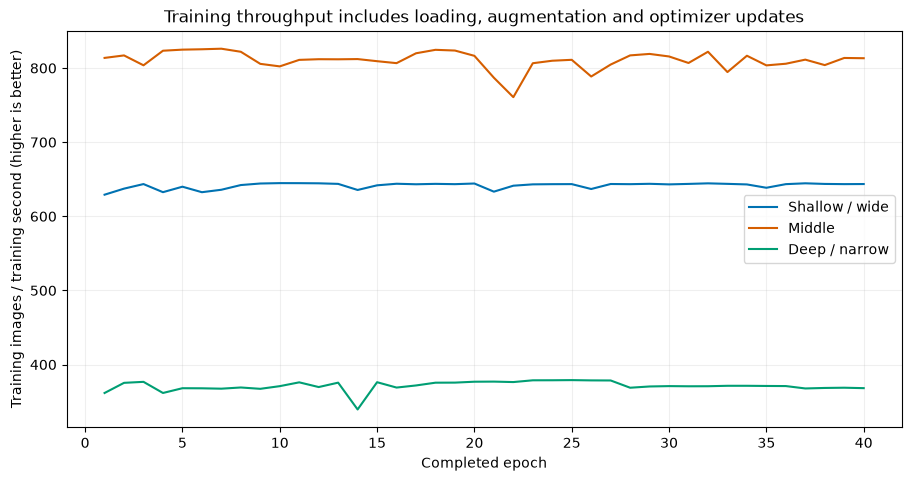

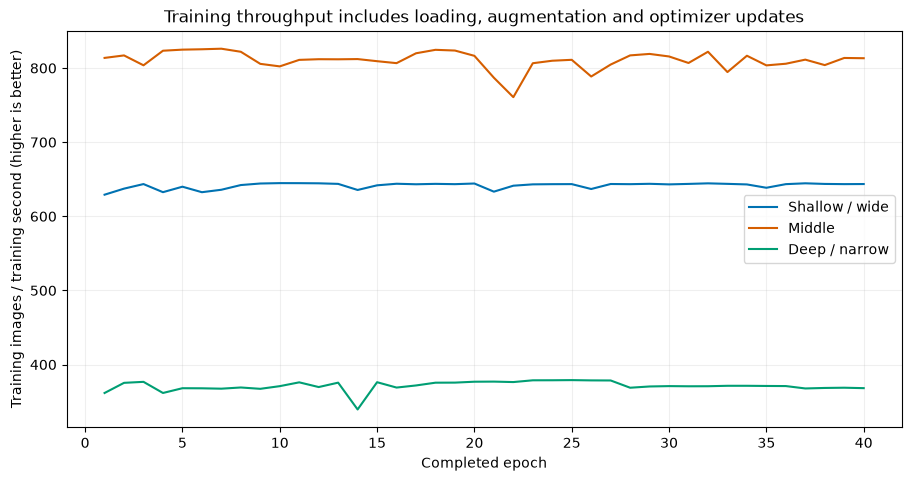

In [18]:
plot_throughput(run)

### Memory snapshots

Inspect the available memory counters without empty backend panels.

**Inputs:** Saved epoch-boundary process and accelerator allocations.

**Output:** Separate available memory panels, all shapes together.

**Interpretation:** RSS, MPS live allocation and MPS driver allocation overlap conceptually and must not be added. Snapshots do not prove the fit’s peak memory.

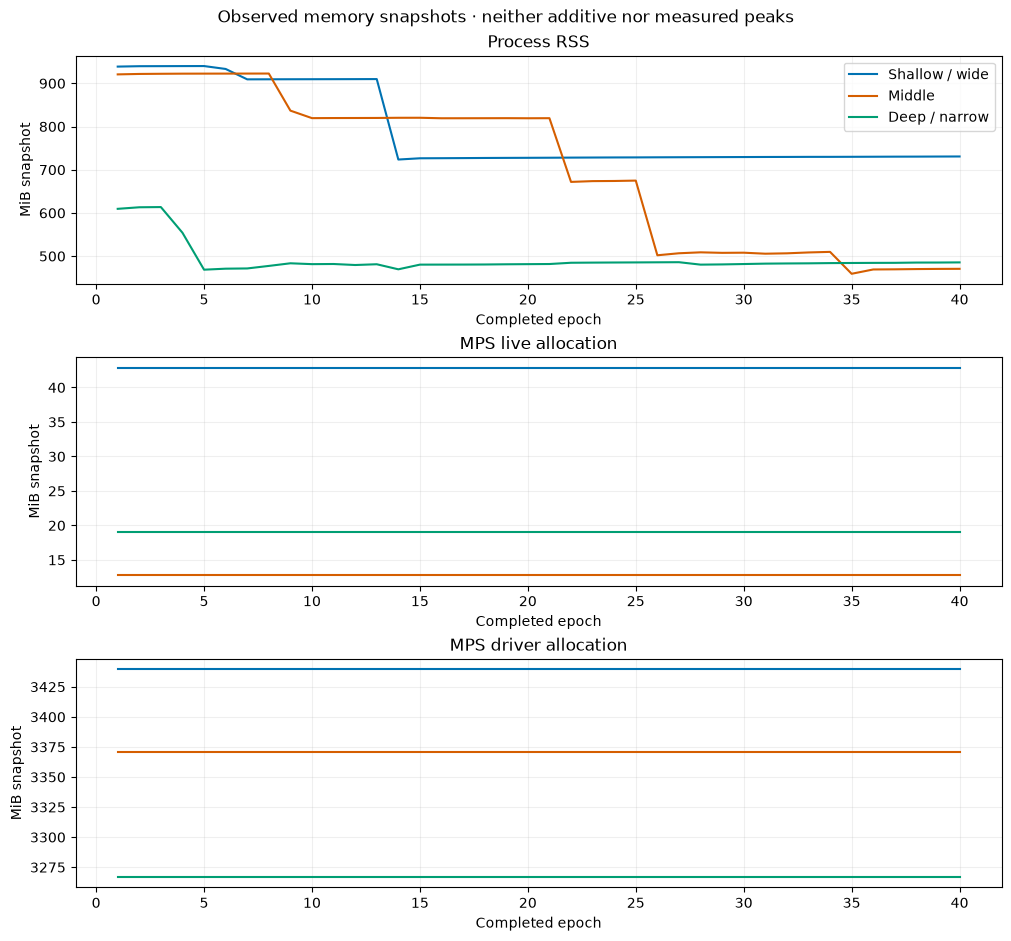

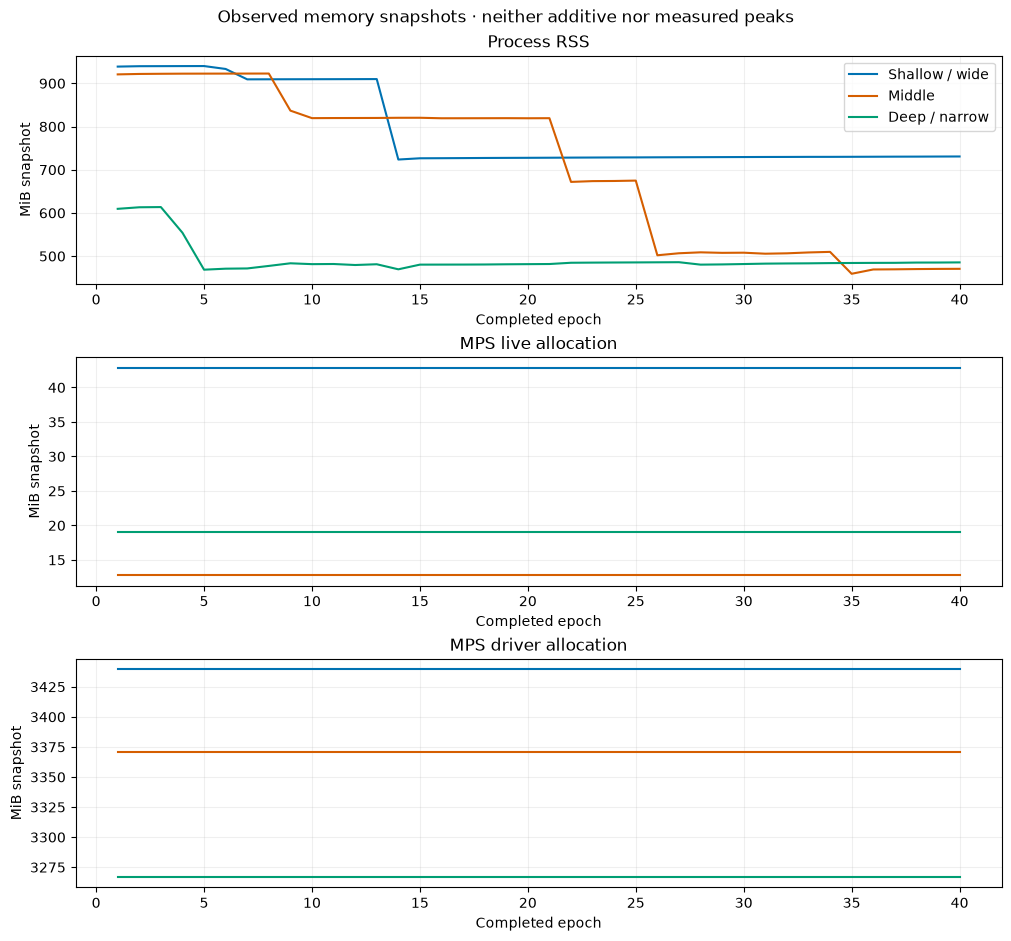

In [19]:
plot_memory(run)

### Optional TensorBoard

Open the saved visual training monitor.

**Inputs:** TensorBoard events already written by training fits.

**Output:** A notebook TensorBoard view when explicitly enabled.

**Interpretation:** CSV/JSON remain the reporting source of truth. Opening the viewer does not train or profile a model.

In [20]:
if SHOW_TENSORBOARD:
    from IPython import get_ipython
    get_ipython().run_line_magic("load_ext", "tensorboard")
    get_ipython().run_line_magic("tensorboard", f"--logdir {run.path / 'tensorboard'}")
else:
    print("Not executed: TensorBoard viewer disabled")

Not executed: TensorBoard viewer disabled


## Freeze, then test

Enable held-out evaluation only after all three fits complete. The freeze fixes checkpoint hashes from validation evidence before any test predictions. Test error review is descriptive; do not use it to retune this experiment and still call the same test a fresh confirmation.

### Freeze all selections

Verify and freeze exactly three validation-selected checkpoints.

**Inputs:** Completed compatible fits.

**Output:** selection.json with each selected epoch and checkpoint hash.

**Interpretation:** Incomplete models block this action.

In [21]:
freeze_selection(run, data) if RUN_TEST_EVALUATION else print("Not executed: test evaluation disabled")

{'run_identity': {'run_uuid': '887694eb92d94ce2890c9100097caff1',
  'protocol': 'eurosat-width-depth-v3',
  'config_hash': 'a3f472af4384d41e2ec90439ca15b08c73e97404aa0172b286f202ea33e9fdf3',
  'source_hash': '2a30f3b9ab5498ba9188de5daa240c15b9171cce6b44768680cae29ea58c1933',
  'environment_hash': 'da368f1a5dde846500522a7acbf8ad1f9e61d348ad2fd4d5c32cb9f0c6eac69b',
  'device': 'mps',
  'created_at': '2026-09-23T11:00:28.164120+00:00'},
 'data_identity': '82e6e69a437f62d31cb0893ef2c1e63cf7a8a3f1ea4684a5781e13d29d4f9286',
 'identity_sha256': '7e4e549931816d7d94b6c618c63a41b1deb929a016ea622a455d4ffb620ba08b',
 'selected': {'shallow_wide': {'epoch': 34,
   'sha256': 'df077b72972154334d2dfc1f226ef356772ebb6fb690102f7463df49c5035a45',
   'file': 'models/shallow_wide/seed_42/checkpoints/epoch_034.pt',
   'parameter_count': 691834},
  'middle': {'epoch': 34,
   'sha256': '5c10355dde5ec5c63bbef4eac4b58e2454ff90d11948ac18dd5384a76e5a73f2',
   'file': 'models/middle/seed_42/checkpoints/epoch_034.pt

### Test — Shallow / wide

Evaluate exactly this frozen checkpoint, or verify and reuse its saved predictions.

**Inputs:** The frozen checkpoint and published spatial test images.

**Output:** Accuracy, macro F1, confusion counts, per-class metrics and stable prediction IDs.

**Interpretation:** Accuracy counts correct images equally; macro F1 averages class F1 equally. The training-majority final-class baseline is included as a simple context.

In [22]:
evaluate_fit(run, data, "shallow_wide") if RUN_TEST_EVALUATION else print("Not executed: test evaluation disabled")

Test: shallow_wide:   0%|          | 0/22 [00:00<?, ?it/s]

{'accuracy': 0.8981481481481481,
 'macro_f1': 0.8808780816223288,
 'examples': 5400,
 'definitions': {'accuracy': 'correct images / all test images',
  'macro_f1': 'equal-weight mean of class F1; missing true/predicted class is undefined',
  'precision': 'zero if a class is never predicted; predicted_count is reported'},
 'variant': 'shallow_wide',
 'seed': 42,
 'partition': 'test',
 'loss': 0.3765325927734375,
 'parameter_count': 691834,
 'selected_epoch': 34,
 'identity_sha256': '6aad08beafdb8ed1e9879dcdc6f3f90bcb9264e5d6258cce0ffbdc09bd3d40ae',
 'checkpoint_sha256': 'df077b72972154334d2dfc1f226ef356772ebb6fb690102f7463df49c5035a45',
 'confusion_matrix': [[624, 0, 32, 34, 0, 5, 39, 0, 40, 44],
  [0, 1065, 2, 0, 0, 4, 0, 0, 0, 6],
  [24, 36, 647, 2, 18, 2, 49, 7, 19, 12],
  [0, 0, 0, 330, 8, 0, 0, 0, 2, 0],
  [0, 0, 1, 3, 346, 0, 2, 1, 0, 0],
  [2, 6, 18, 0, 0, 87, 1, 0, 0, 1],
  [3, 1, 56, 0, 0, 1, 246, 0, 0, 0],
  [0, 0, 10, 1, 13, 0, 2, 481, 0, 0],
  [11, 2, 1, 5, 0, 2, 4, 0, 303, 

### Test — Middle

Evaluate exactly this frozen checkpoint, or verify and reuse its saved predictions.

**Inputs:** The frozen checkpoint and published spatial test images.

**Output:** Accuracy, macro F1, confusion counts, per-class metrics and stable prediction IDs.

**Interpretation:** Accuracy counts correct images equally; macro F1 averages class F1 equally. The training-majority final-class baseline is included as a simple context.

In [23]:
evaluate_fit(run, data, "middle") if RUN_TEST_EVALUATION else print("Not executed: test evaluation disabled")

Test: middle:   0%|          | 0/22 [00:00<?, ?it/s]

{'accuracy': 0.9166666666666666,
 'macro_f1': 0.8984330733464108,
 'examples': 5400,
 'definitions': {'accuracy': 'correct images / all test images',
  'macro_f1': 'equal-weight mean of class F1; missing true/predicted class is undefined',
  'precision': 'zero if a class is never predicted; predicted_count is reported'},
 'variant': 'middle',
 'seed': 42,
 'partition': 'test',
 'loss': 0.2983289252387153,
 'parameter_count': 696618,
 'selected_epoch': 34,
 'identity_sha256': '76d17a4b90ab3f15637b8708d16530cf8c8339aaaa7631053b92b04b569a561d',
 'checkpoint_sha256': '5c10355dde5ec5c63bbef4eac4b58e2454ff90d11948ac18dd5384a76e5a73f2',
 'confusion_matrix': [[653, 0, 32, 15, 1, 9, 42, 0, 26, 40],
  [0, 1068, 1, 0, 0, 3, 0, 0, 0, 5],
  [6, 38, 712, 1, 5, 2, 45, 0, 5, 2],
  [0, 0, 0, 334, 4, 0, 0, 0, 2, 0],
  [0, 0, 3, 3, 340, 0, 5, 2, 0, 0],
  [1, 7, 22, 0, 0, 82, 1, 0, 1, 1],
  [3, 1, 49, 0, 0, 0, 254, 0, 0, 0],
  [0, 0, 27, 0, 10, 0, 2, 468, 0, 0],
  [8, 0, 3, 7, 0, 1, 0, 0, 309, 3],
  [1, 0

### Test — Deep / narrow

Evaluate exactly this frozen checkpoint, or verify and reuse its saved predictions.

**Inputs:** The frozen checkpoint and published spatial test images.

**Output:** Accuracy, macro F1, confusion counts, per-class metrics and stable prediction IDs.

**Interpretation:** Accuracy counts correct images equally; macro F1 averages class F1 equally. The training-majority final-class baseline is included as a simple context.

In [24]:
evaluate_fit(run, data, "deep_narrow") if RUN_TEST_EVALUATION else print("Not executed: test evaluation disabled")

Test: deep_narrow:   0%|          | 0/22 [00:00<?, ?it/s]

{'accuracy': 0.8970370370370371,
 'macro_f1': 0.8771016584216804,
 'examples': 5400,
 'definitions': {'accuracy': 'correct images / all test images',
  'macro_f1': 'equal-weight mean of class F1; missing true/predicted class is undefined',
  'precision': 'zero if a class is never predicted; predicted_count is reported'},
 'variant': 'deep_narrow',
 'seed': 42,
 'partition': 'test',
 'loss': 0.387215259693287,
 'parameter_count': 697344,
 'selected_epoch': 28,
 'identity_sha256': '8807e2ad5fd5f853b74f32e36d5f3f92410daeb5fba8bb628f8a1e3d1c87d8e1',
 'checkpoint_sha256': 'f9110cb1355029afcbfe320909b4c6e50e6870b5a63bdd7f747c8eccf3721968',
 'confusion_matrix': [[669, 0, 24, 13, 0, 5, 62, 0, 21, 24],
  [0, 1073, 0, 0, 0, 1, 0, 0, 1, 2],
  [8, 42, 562, 2, 8, 9, 113, 30, 41, 1],
  [0, 0, 0, 334, 3, 0, 0, 0, 3, 0],
  [0, 0, 0, 1, 341, 0, 4, 7, 0, 0],
  [2, 6, 16, 0, 0, 89, 1, 0, 0, 1],
  [0, 1, 36, 0, 0, 12, 257, 1, 0, 0],
  [0, 0, 4, 0, 16, 0, 3, 484, 0, 0],
  [8, 1, 2, 2, 0, 2, 3, 0, 311, 2],


### Joint quality table

Compare the three held-out results in one place.

**Inputs:** All three saved, verified test results.

**Output:** Metrics, selected epochs and parameter counts.

**Interpretation:** Report exact observed differences. One seed does not estimate seed variability or establish general superiority.

In [25]:
quality_table(run) if RUN_TEST_EVALUATION else print("Not executed: no test table requested")

,accuracy,checkpoint_sha256,examples,identity_sha256,loss,macro_f1,majority_baseline_accuracy,majority_baseline_class,parameter_count,partition,seed,selected_epoch,variant
0,0.898148,df077b72972154334d2dfc1f226ef356772ebb6fb69010...,5400,6aad08beafdb8ed1e9879dcdc6f3f90bcb9264e5d6258c...,0.376533,0.880878,0.093889,Residential,691834,test,42,34,shallow_wide
1,0.916667,5c10355dde5ec5c63bbef4eac4b58e2454ff90d11948ac...,5400,76d17a4b90ab3f15637b8708d16530cf8c8339aaaa7631...,0.298329,0.898433,0.093889,Residential,696618,test,42,34,middle
2,0.897037,f9110cb1355029afcbfe320909b4c6e50e6870b5a63bdd...,5400,8807e2ad5fd5f853b74f32e36d5f3f92410daeb5fba8bb...,0.387215,0.877102,0.093889,Residential,697344,test,42,28,deep_narrow


### Accuracy and macro F1

Visualize both quality measures for all shapes.

**Inputs:** Saved test accuracy and macro F1.

**Output:** Two clearly labeled bars per comparison panel.

**Interpretation:** Both axes are percentages and higher is better. The figure deliberately includes no multi-seed error bars.

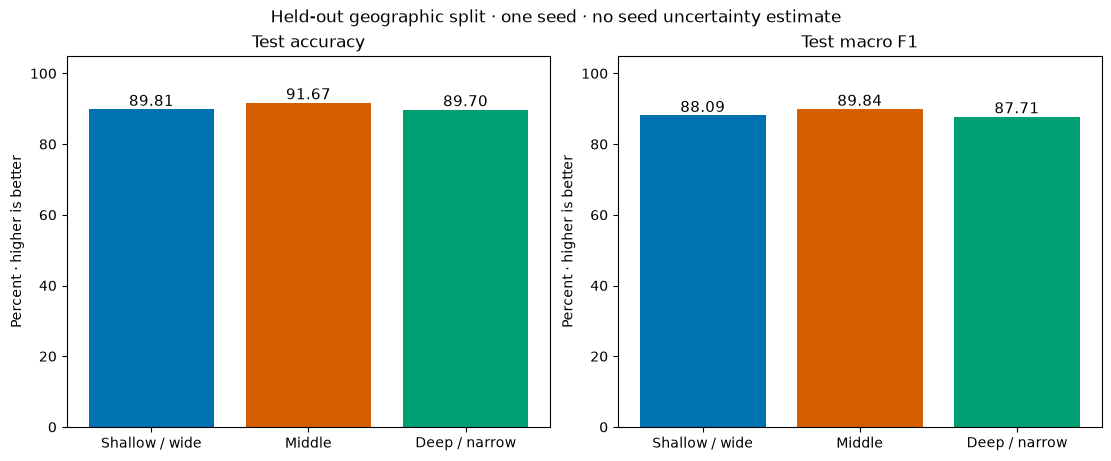

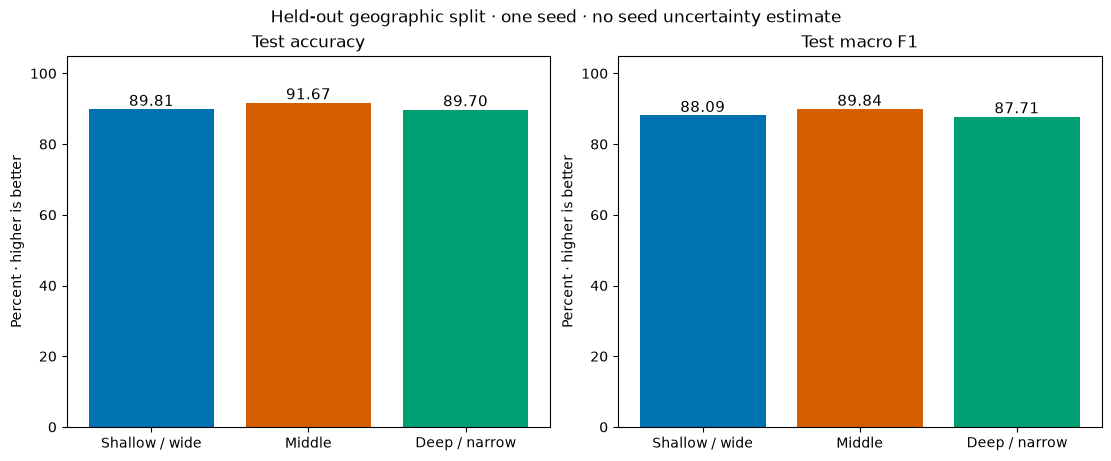

In [26]:
plot_quality(run) if RUN_TEST_EVALUATION else print("Not executed: no test figure requested")

### Class confusions

Inspect which real land-cover classes are confused.

**Inputs:** Verified saved confusion matrices.

**Output:** One readable matrix per shape in a joint figure.

**Interpretation:** Rows are true labels; each row is divided by its test support. Strong diagonal values indicate correct predictions. Off-diagonal patterns suggest hypotheses, not proven mechanisms.

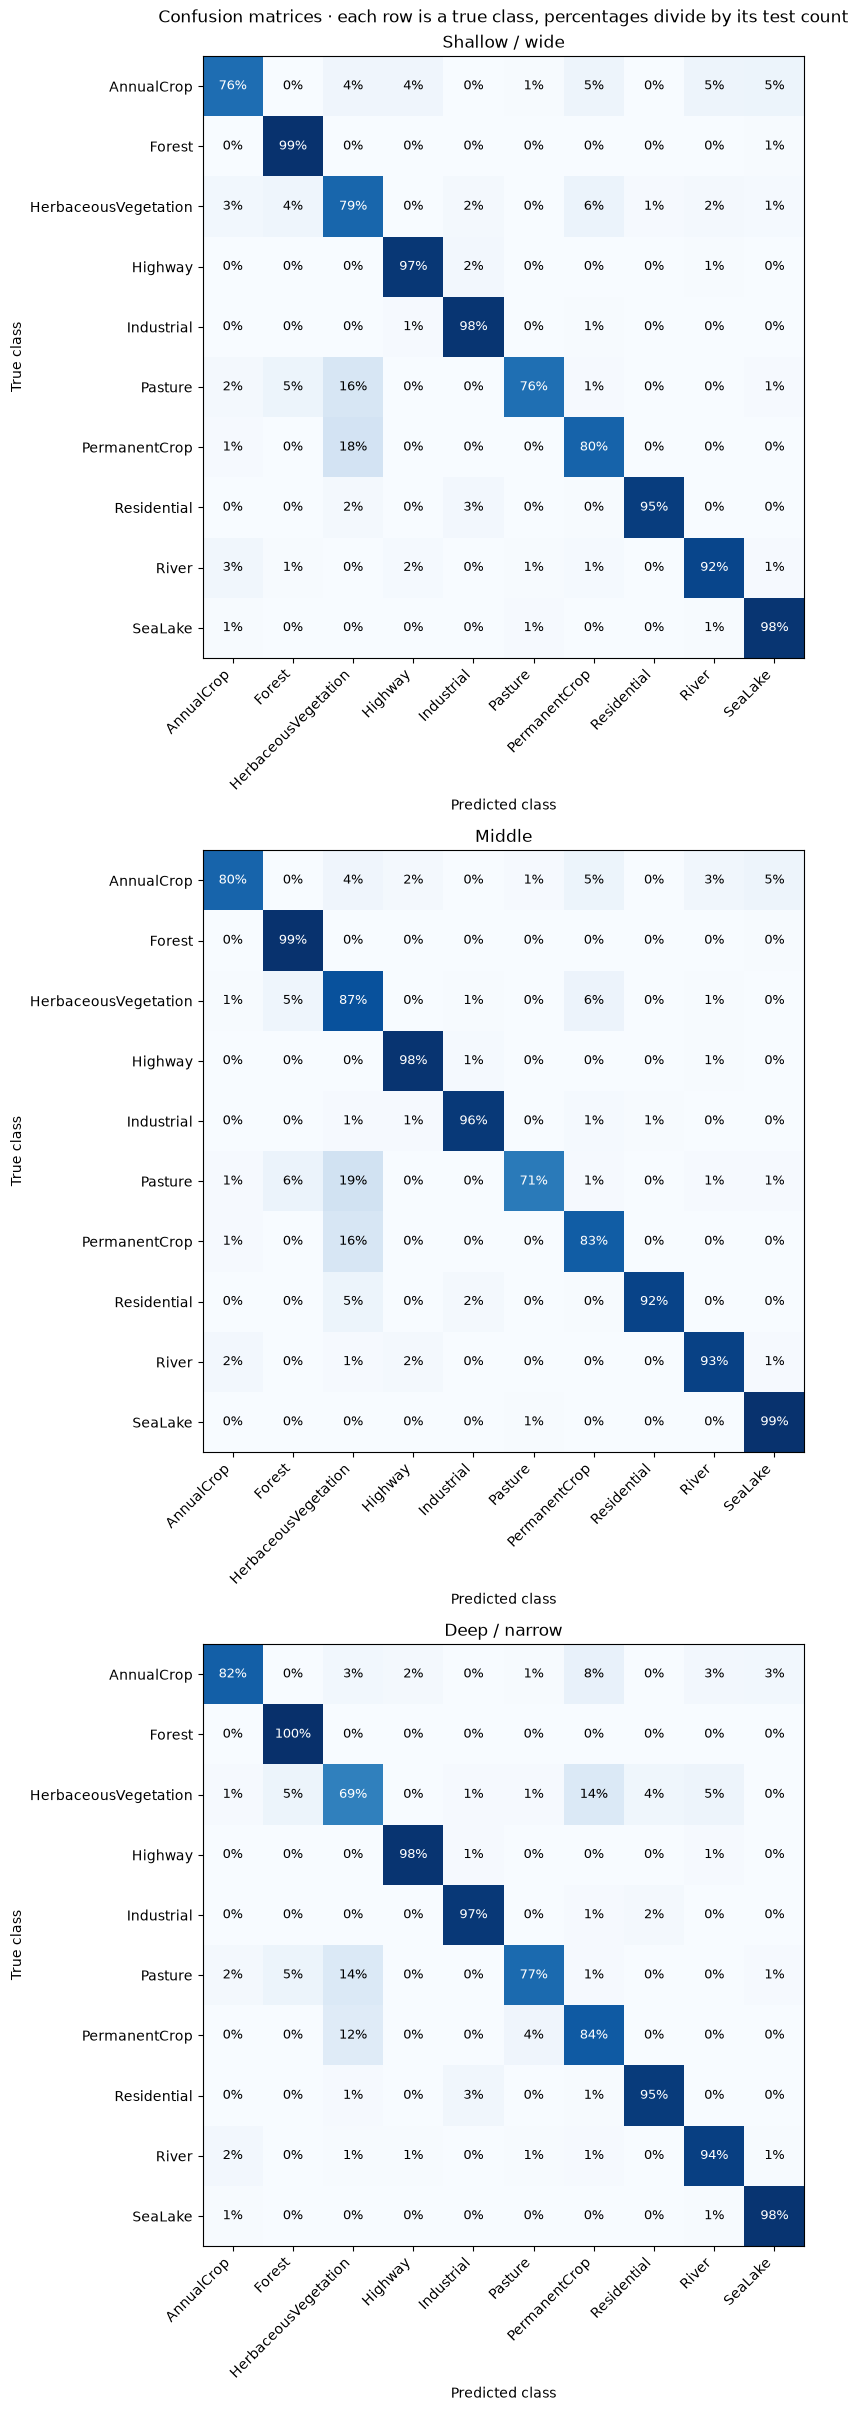

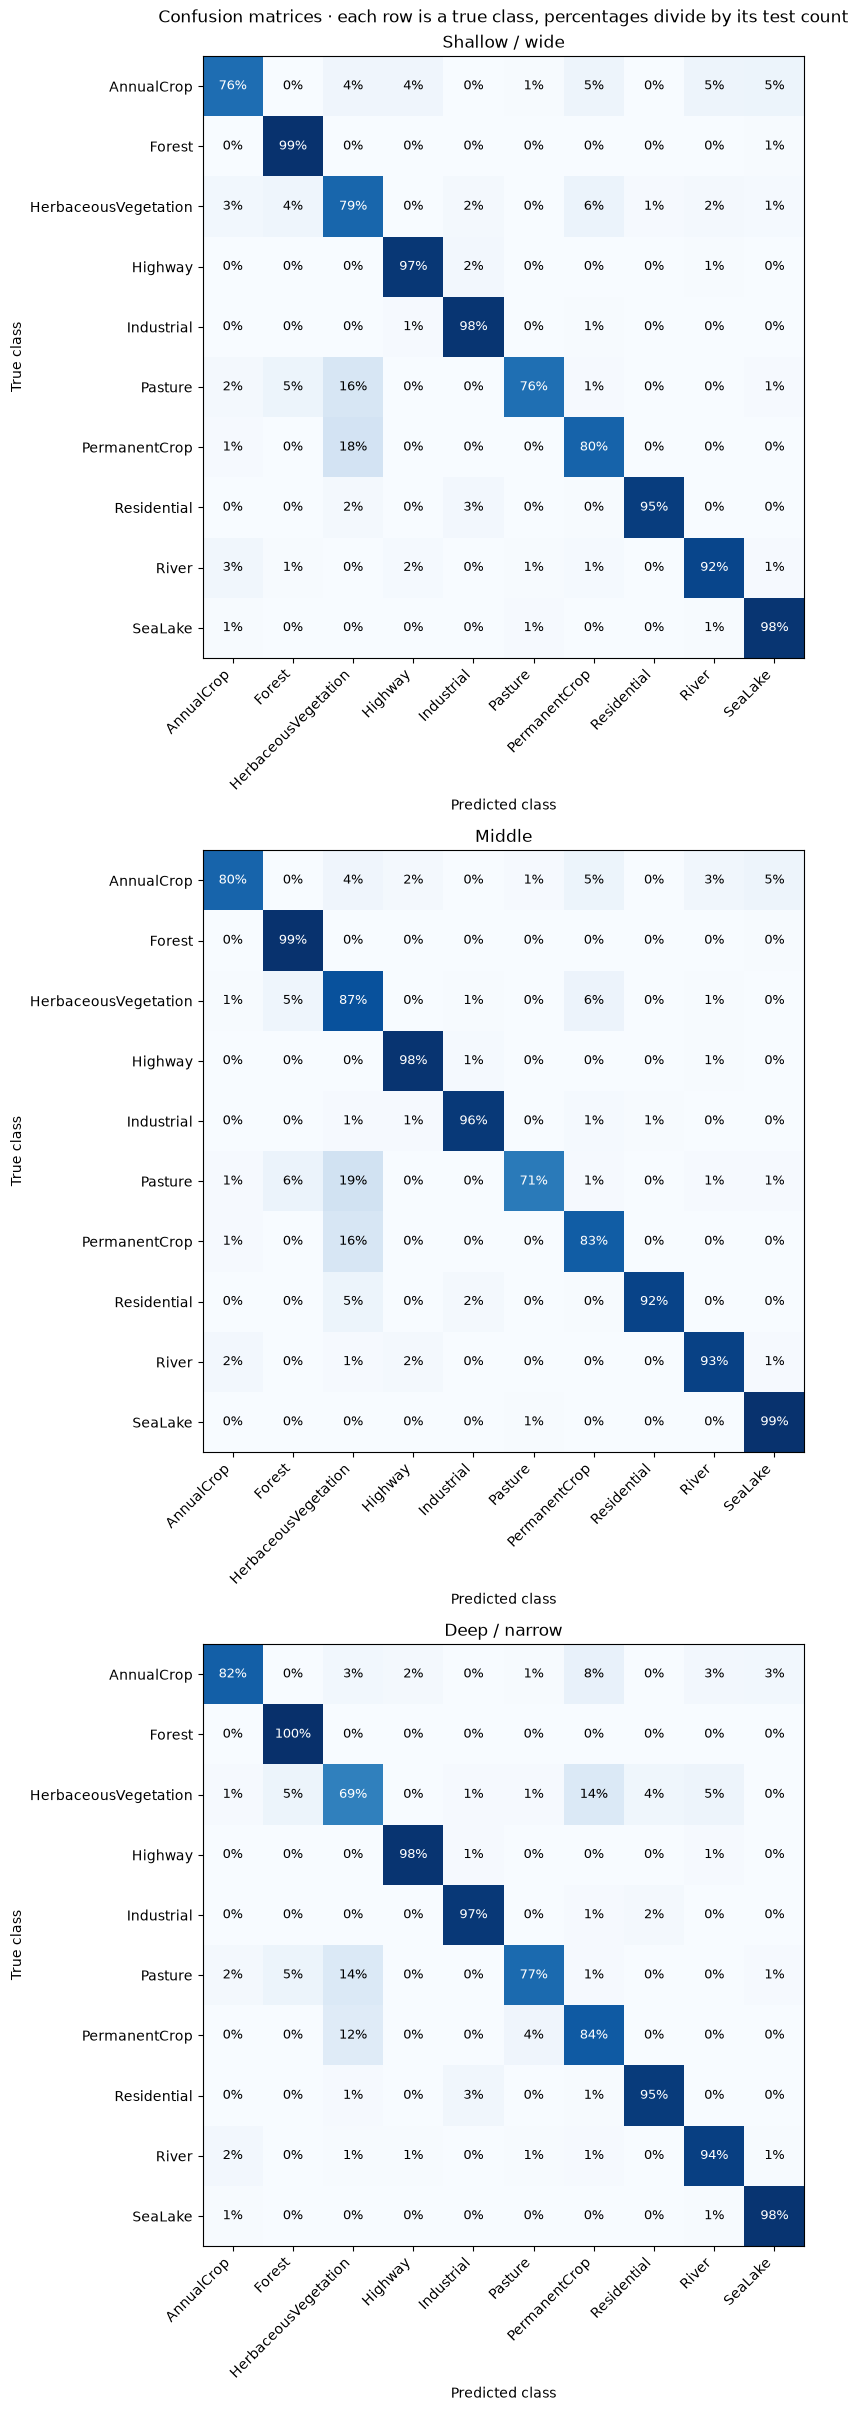

In [27]:
plot_confusions(run) if RUN_TEST_EVALUATION else print("Not executed: no confusion figure requested")

### Failure review

Review high-confidence mistakes across all three shapes.

**Inputs:** Saved test prediction files, not new model calls.

**Output:** A joint failure table with stable image IDs, truth, predicted class and confidence.

**Interpretation:** Confidence is not calibrated certainty. The displayed mistakes are selected for diagnosis, not an unbiased sample of overall error frequency.

In [28]:
failure_table(run) if RUN_TEST_EVALUATION else print("Not executed: failure review disabled")

,variant,confidence_rank_within_errors,sample_id,true_class,predicted_class,confidence
0,shallow_wide,1,Pasture_889.jpg,Pasture,Forest,0.999999
1,shallow_wide,2,AnnualCrop_1627.jpg,AnnualCrop,HerbaceousVegetation,0.999912
2,shallow_wide,3,AnnualCrop_35.jpg,AnnualCrop,PermanentCrop,0.999880
3,shallow_wide,4,AnnualCrop_1191.jpg,AnnualCrop,SeaLake,0.999793
4,shallow_wide,5,AnnualCrop_999.jpg,AnnualCrop,PermanentCrop,0.999719
5,middle,1,AnnualCrop_1114.jpg,AnnualCrop,SeaLake,0.999996
6,middle,2,Pasture_889.jpg,Pasture,Forest,0.999987
7,middle,3,AnnualCrop_1191.jpg,AnnualCrop,SeaLake,0.999952
8,middle,4,PermanentCrop_1328.jpg,PermanentCrop,HerbaceousVegetation,0.999951
9,middle,5,AnnualCrop_759.jpg,AnnualCrop,River,0.999938


### Accuracy versus training cost

Compare observed quality with the actual fit cost.

**Inputs:** Saved test accuracy and complete fit timing receipts.

**Output:** All shapes on one accuracy/runtime chart.

**Interpretation:** A shape with missing total timings is omitted rather than assigned zero cost. These points describe this recipe and hardware, not an architectural law.

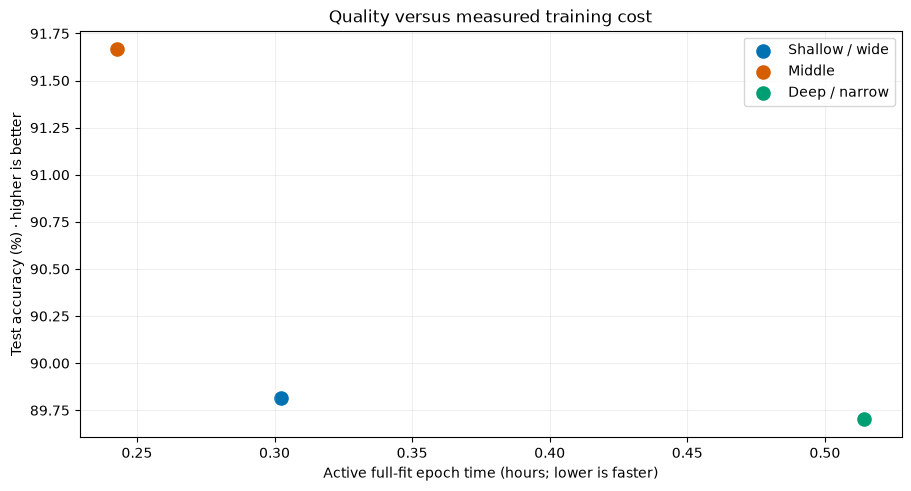

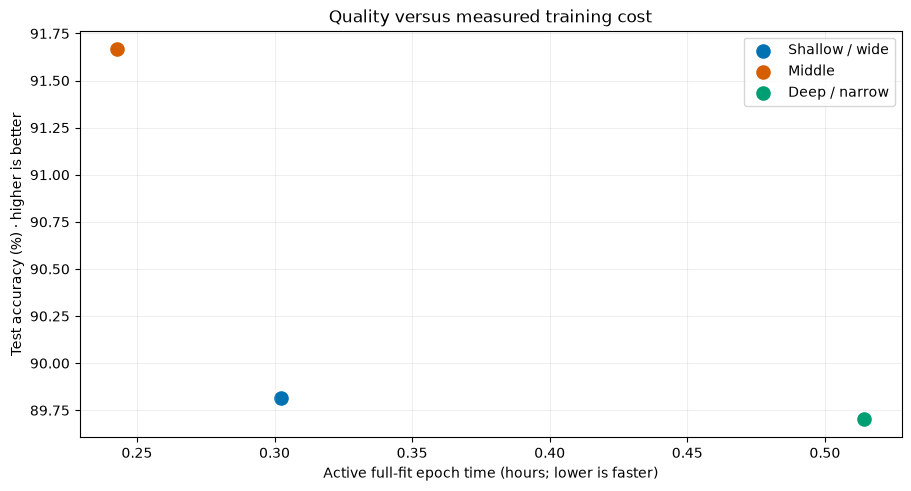

In [29]:
plot_accuracy_runtime(run) if RUN_TEST_EVALUATION else print("Not executed: quality/cost figure disabled")

## Optional bounded inference benchmark

These cells are disabled by default. Each named model uses the same validation request IDs, batch sizes 1 and 64, five warm-ups and 30 measurements. Timings synchronize the backend and measure the forward pass only. Loading, normalization, transfer and output formatting are excluded; one sequential block is not a controlled paired optimization experiment.

### Inference cost — Shallow / wide

Benchmark only this saved model when enabled.

**Inputs:** Frozen model and deterministic validation requests.

**Output:** Individual latencies, p50/p95, throughput and memory snapshots.

**Interpretation:** The model-only boundary makes the numbers comparable within this notebook. These are neither end-to-end serving latencies nor memory peaks.

In [30]:
benchmark_fit(run, data, "shallow_wide") if RUN_BENCHMARKS else print("Not executed: optional benchmark disabled")

{'identity': {'run': {'run_uuid': '887694eb92d94ce2890c9100097caff1',
   'protocol': 'eurosat-width-depth-v3',
   'config_hash': 'a3f472af4384d41e2ec90439ca15b08c73e97404aa0172b286f202ea33e9fdf3',
   'source_hash': '2a30f3b9ab5498ba9188de5daa240c15b9171cce6b44768680cae29ea58c1933',
   'environment_hash': 'da368f1a5dde846500522a7acbf8ad1f9e61d348ad2fd4d5c32cb9f0c6eac69b',
   'device': 'mps',
   'created_at': '2026-09-23T11:00:28.164120+00:00'},
  'data': '82e6e69a437f62d31cb0893ef2c1e63cf7a8a3f1ea4684a5781e13d29d4f9286',
  'configuration_sha256': 'a3f472af4384d41e2ec90439ca15b08c73e97404aa0172b286f202ea33e9fdf3',
  'variant': 'shallow_wide',
  'seed': 42,
  'stage': 'models'},
 'checkpoint_sha256': 'df077b72972154334d2dfc1f226ef356772ebb6fb690102f7463df49c5035a45',
 'results': [{'batch_size': 1,
   'requests': 30,
   'p50_ms': 2.281166503962595,
   'p95_ms': 2.908732998184859,
   'images_per_second': 421.7128177546639,
   'process_rss_mib': 603.375,
   'mps_live_mib': 2.718994140625,
  

### Inference cost — Middle

Benchmark only this saved model when enabled.

**Inputs:** Frozen model and deterministic validation requests.

**Output:** Individual latencies, p50/p95, throughput and memory snapshots.

**Interpretation:** The model-only boundary makes the numbers comparable within this notebook. These are neither end-to-end serving latencies nor memory peaks.

In [31]:
benchmark_fit(run, data, "middle") if RUN_BENCHMARKS else print("Not executed: optional benchmark disabled")

{'identity': {'run': {'run_uuid': '887694eb92d94ce2890c9100097caff1',
   'protocol': 'eurosat-width-depth-v3',
   'config_hash': 'a3f472af4384d41e2ec90439ca15b08c73e97404aa0172b286f202ea33e9fdf3',
   'source_hash': '2a30f3b9ab5498ba9188de5daa240c15b9171cce6b44768680cae29ea58c1933',
   'environment_hash': 'da368f1a5dde846500522a7acbf8ad1f9e61d348ad2fd4d5c32cb9f0c6eac69b',
   'device': 'mps',
   'created_at': '2026-09-23T11:00:28.164120+00:00'},
  'data': '82e6e69a437f62d31cb0893ef2c1e63cf7a8a3f1ea4684a5781e13d29d4f9286',
  'configuration_sha256': 'a3f472af4384d41e2ec90439ca15b08c73e97404aa0172b286f202ea33e9fdf3',
  'variant': 'middle',
  'seed': 42,
  'stage': 'models'},
 'checkpoint_sha256': '5c10355dde5ec5c63bbef4eac4b58e2454ff90d11948ac18dd5384a76e5a73f2',
 'results': [{'batch_size': 1,
   'requests': 30,
   'p50_ms': 2.9941669999971054,
   'p95_ms': 3.996324846957577,
   'images_per_second': 321.68332521090275,
   'process_rss_mib': 627.625,
   'mps_live_mib': 2.771240234375,
   'mp

### Inference cost — Deep / narrow

Benchmark only this saved model when enabled.

**Inputs:** Frozen model and deterministic validation requests.

**Output:** Individual latencies, p50/p95, throughput and memory snapshots.

**Interpretation:** The model-only boundary makes the numbers comparable within this notebook. These are neither end-to-end serving latencies nor memory peaks.

In [32]:
benchmark_fit(run, data, "deep_narrow") if RUN_BENCHMARKS else print("Not executed: optional benchmark disabled")

{'identity': {'run': {'run_uuid': '887694eb92d94ce2890c9100097caff1',
   'protocol': 'eurosat-width-depth-v3',
   'config_hash': 'a3f472af4384d41e2ec90439ca15b08c73e97404aa0172b286f202ea33e9fdf3',
   'source_hash': '2a30f3b9ab5498ba9188de5daa240c15b9171cce6b44768680cae29ea58c1933',
   'environment_hash': 'da368f1a5dde846500522a7acbf8ad1f9e61d348ad2fd4d5c32cb9f0c6eac69b',
   'device': 'mps',
   'created_at': '2026-09-23T11:00:28.164120+00:00'},
  'data': '82e6e69a437f62d31cb0893ef2c1e63cf7a8a3f1ea4684a5781e13d29d4f9286',
  'configuration_sha256': 'a3f472af4384d41e2ec90439ca15b08c73e97404aa0172b286f202ea33e9fdf3',
  'variant': 'deep_narrow',
  'seed': 42,
  'stage': 'models'},
 'checkpoint_sha256': 'f9110cb1355029afcbfe320909b4c6e50e6870b5a63bdd7f747c8eccf3721968',
 'results': [{'batch_size': 1,
   'requests': 30,
   'p50_ms': 4.6871250015101396,
   'p95_ms': 5.430393755523253,
   'images_per_second': 213.02978951249403,
   'process_rss_mib': 649.71875,
   'mps_live_mib': 2.794921875,
  

### Joint inference table

Compare available inference measurements.

**Inputs:** Saved benchmark artifacts only.

**Output:** One joint table, or an empty table when not run.

**Interpretation:** p50 is median latency; p95 describes the slower end of this small measured sample. Higher images/second is better; lower latency is better.

In [33]:
benchmark_table(run)

,batch_size,images_per_second,mps_driver_mib,mps_live_mib,p50_ms,p95_ms,process_rss_mib,requests,variant
0,1,421.712818,4176.984375,2.718994,2.281167,2.908733,603.375000,30,shallow_wide
1,64,2620.869996,4225.156250,8.652344,24.347021,24.826598,636.937500,30,shallow_wide
2,1,321.683325,4225.328125,2.771240,2.994167,3.996325,627.625000,30,middle
3,64,2709.921596,4225.500000,8.704590,23.500083,24.219435,660.015625,30,middle
4,1,213.029790,4225.671875,2.794922,4.687125,5.430394,649.718750,30,deep_narrow
5,64,1984.238390,4199.843750,8.728271,32.133625,32.816915,683.093750,30,deep_narrow


### Technical report

Assemble the final report from saved tables and figures.

**Inputs:** All three verified test results, completed epoch records and any existing optional benchmarks.

**Output:** report/technical_report.md.

**Interpretation:** Assembly does not generate missing experiments or plots. The report distinguishes observations, possible explanations, missing measurements and one-seed/spatial-split limitations.

In [34]:
assemble_report(run) if RUN_TEST_EVALUATION else print("Not executed: report needs saved test results")

PosixPath('/Users/biitu/Documents/Growth/labs/eurosat-width-depth/runs/run_001/report/technical_report.md')